In [2]:
from google.colab import drive
import os
import pandas as pd

# Mount Drive của bạn vào môi trường Colab
drive.mount('/content/drive')

# Đường dẫn đến thư mục .vnstock (hãy kiểm tra lại đường dẫn chính xác trong Drive của bạn)
# Thông thường sẽ là: /content/drive/MyDrive/.vnstock
folder_path = '/content/drive/MyDrive/ITEC 2/.vnstock'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Mounted at /content/drive
Đang xử lý 31 mã với Window Step = 2880...


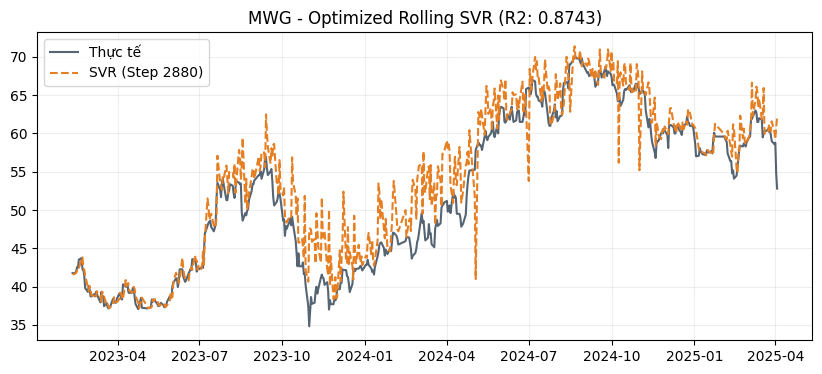

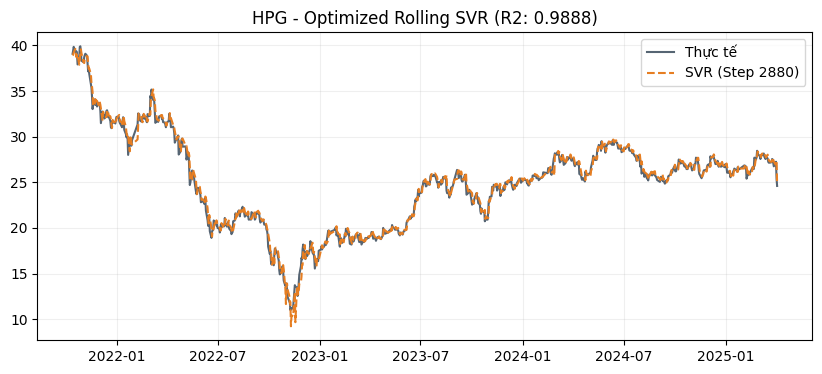

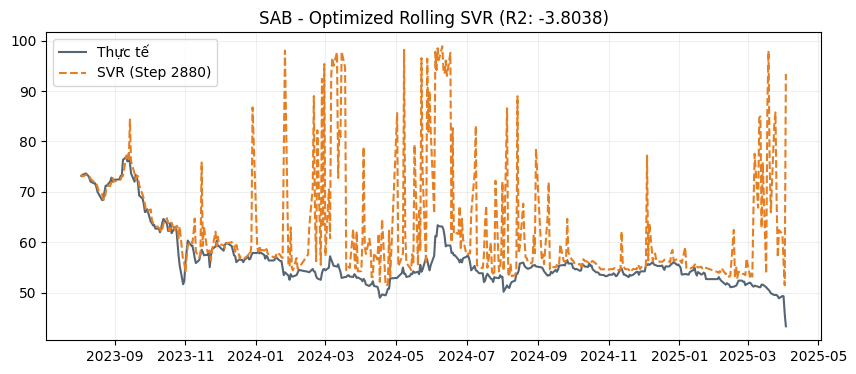

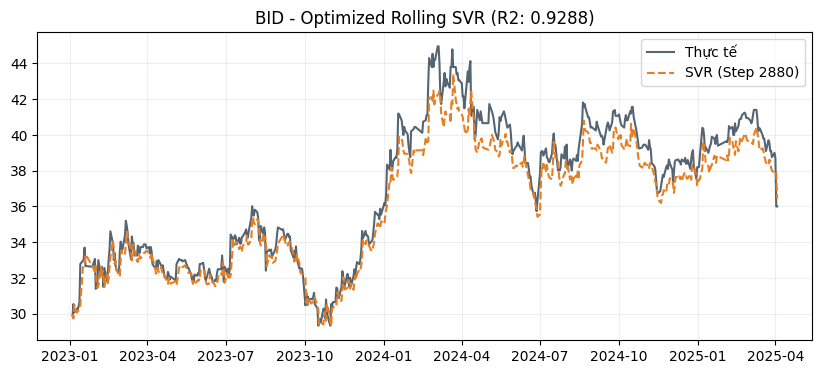

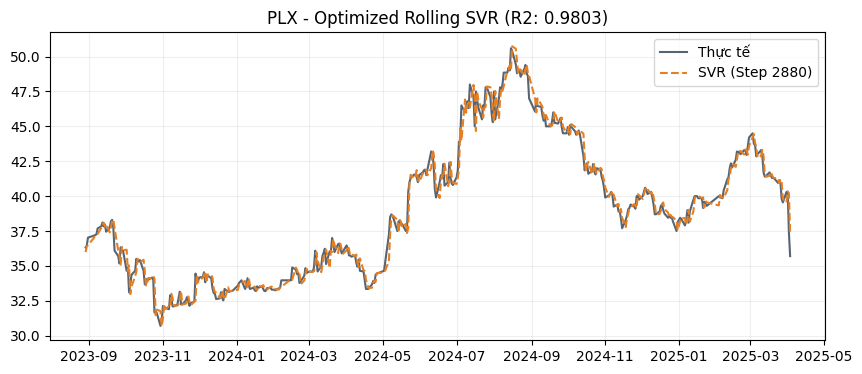

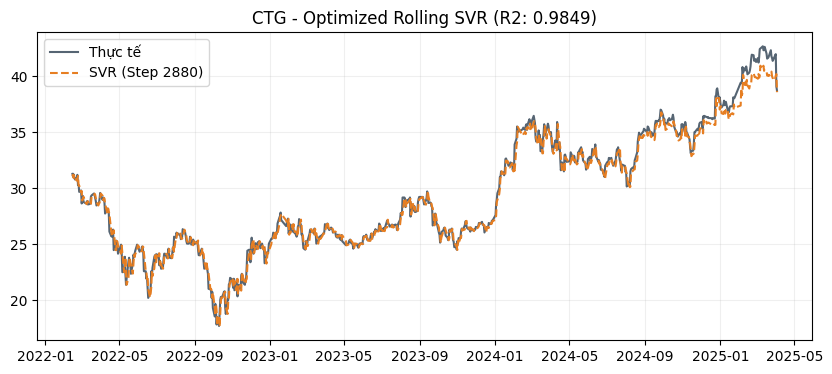

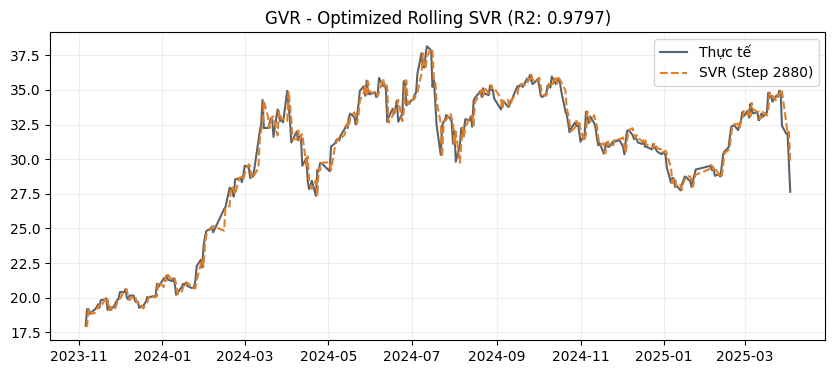

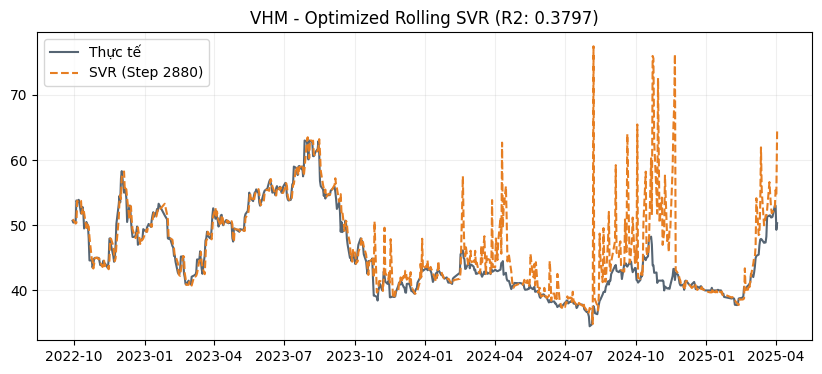

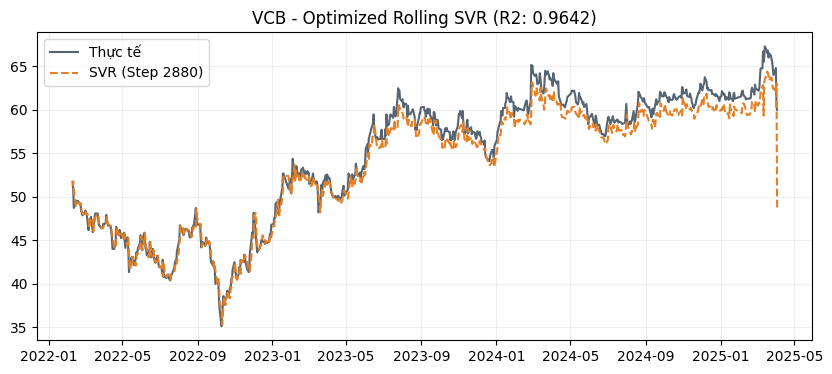

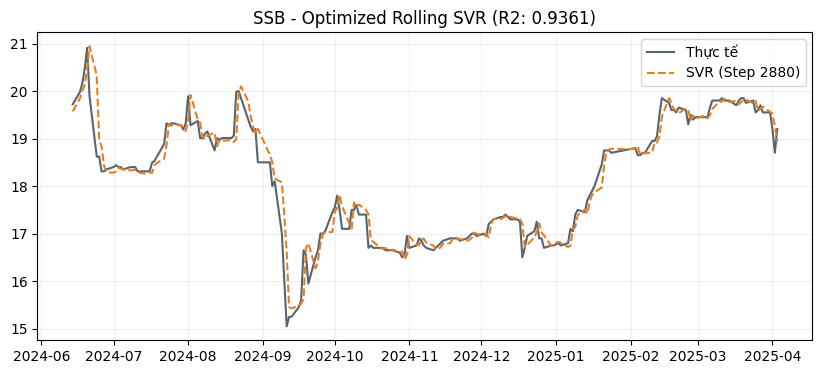

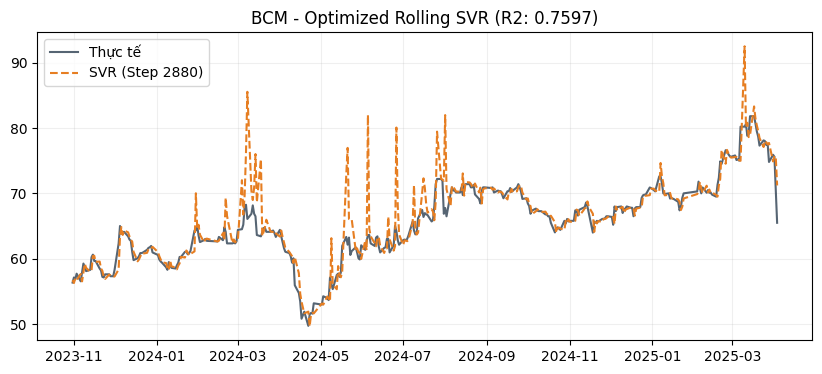

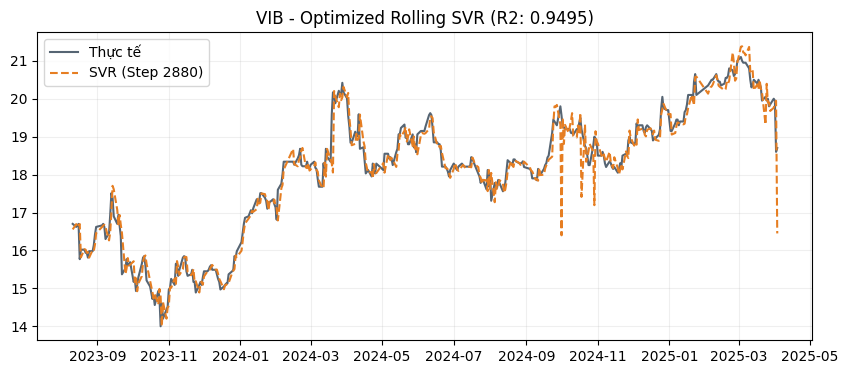

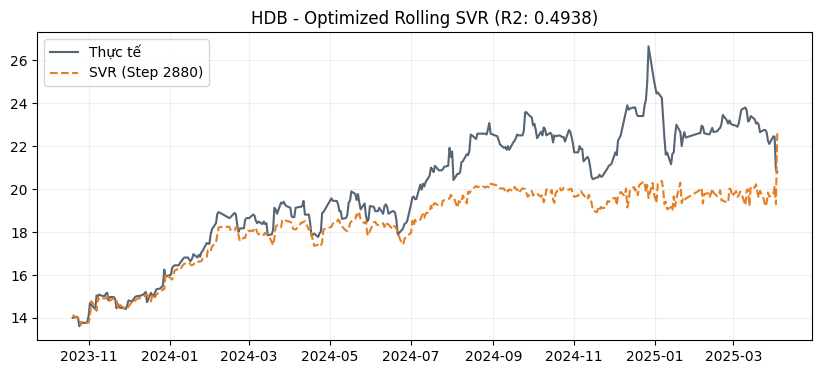

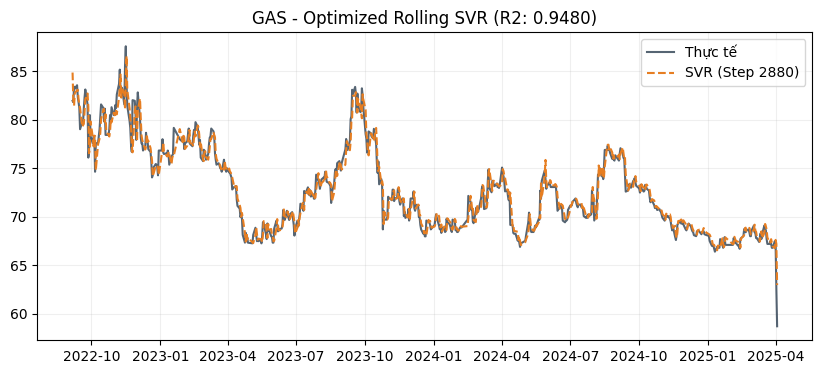

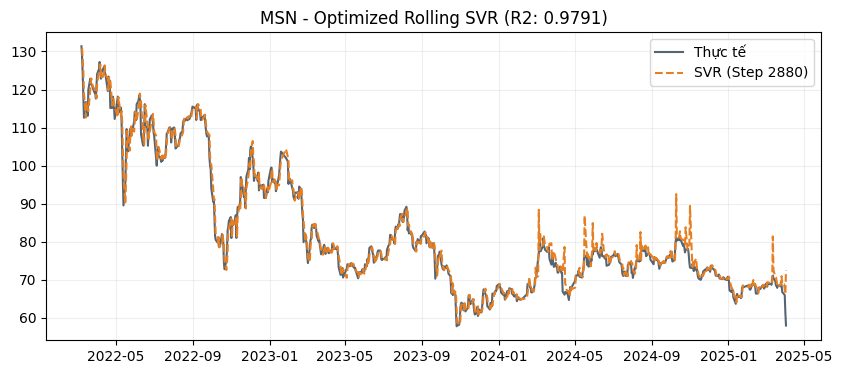

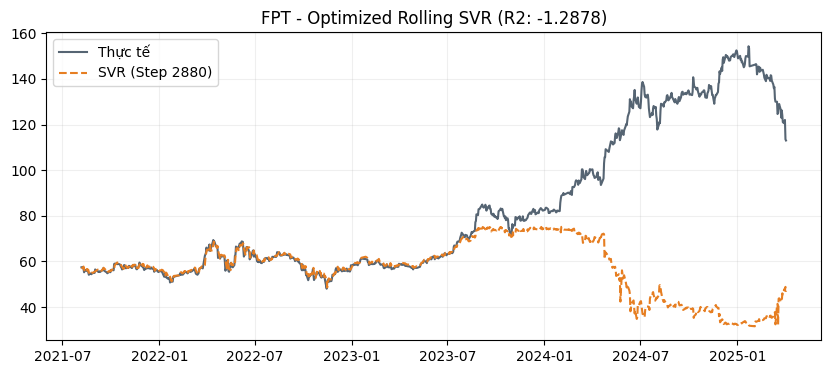

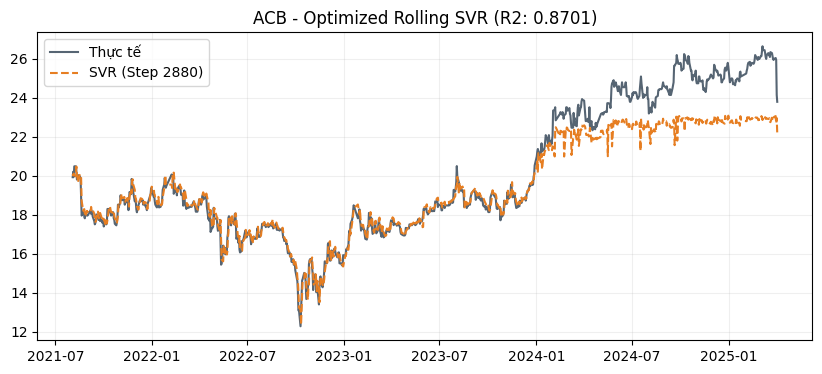

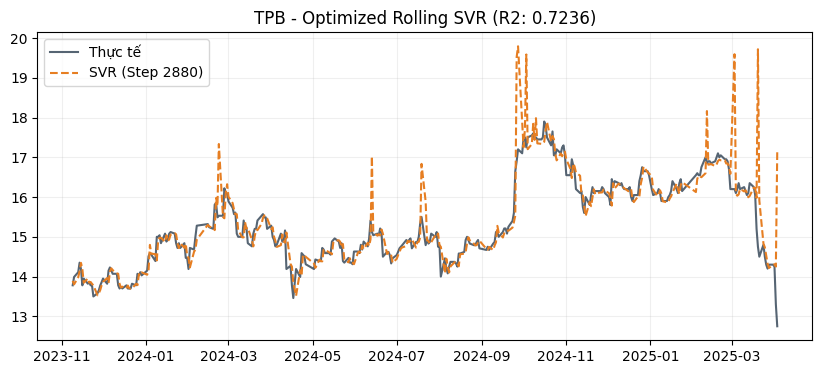

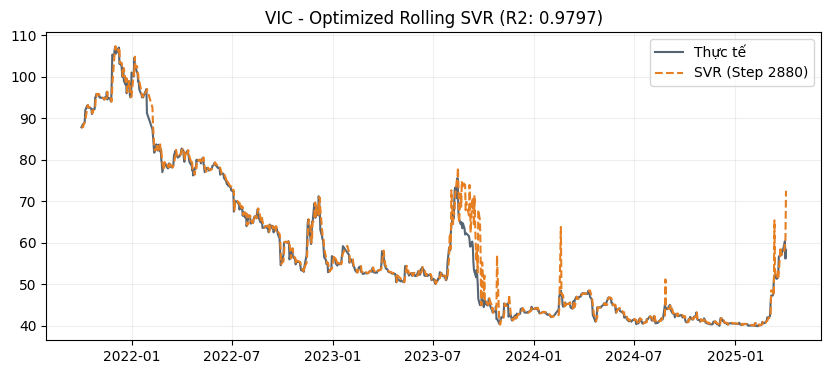

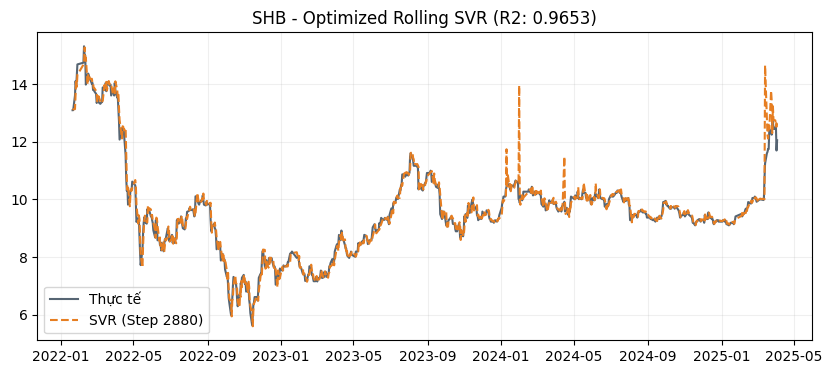

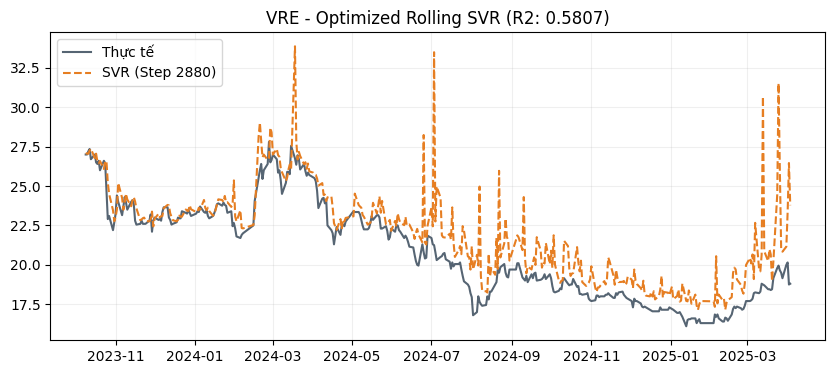

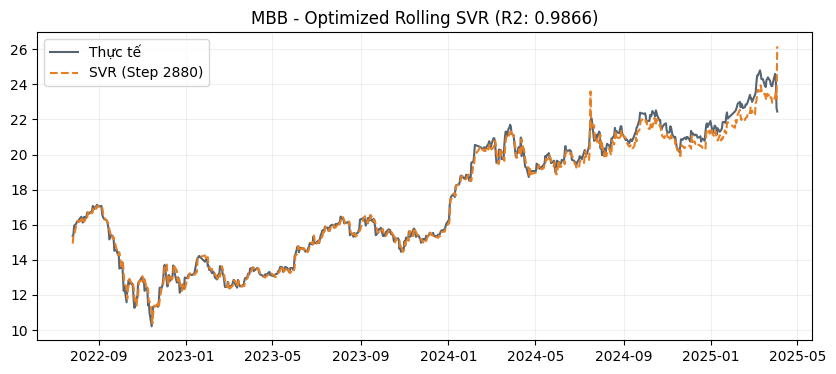

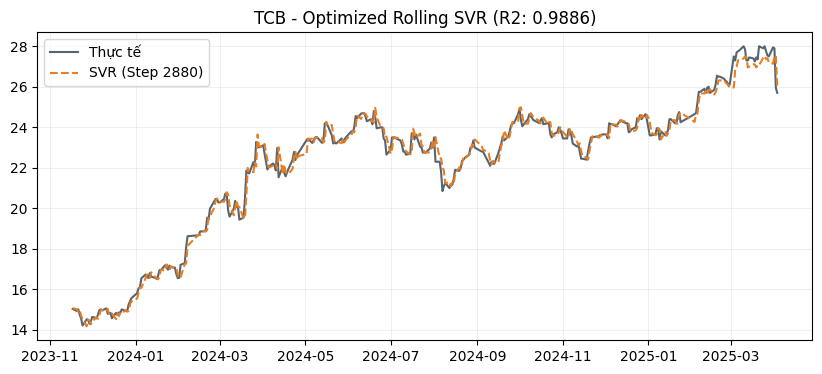

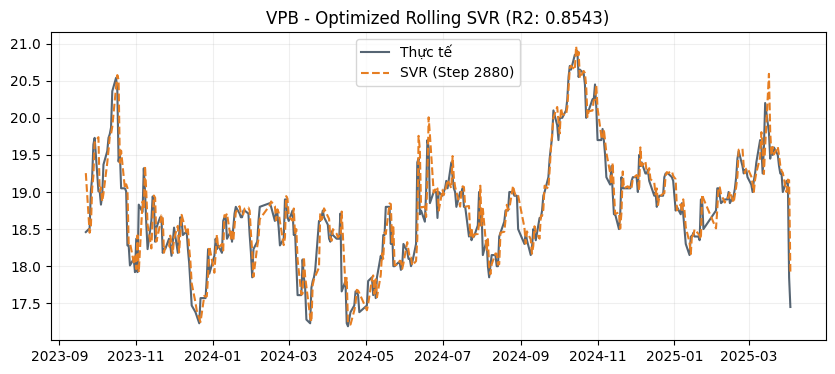

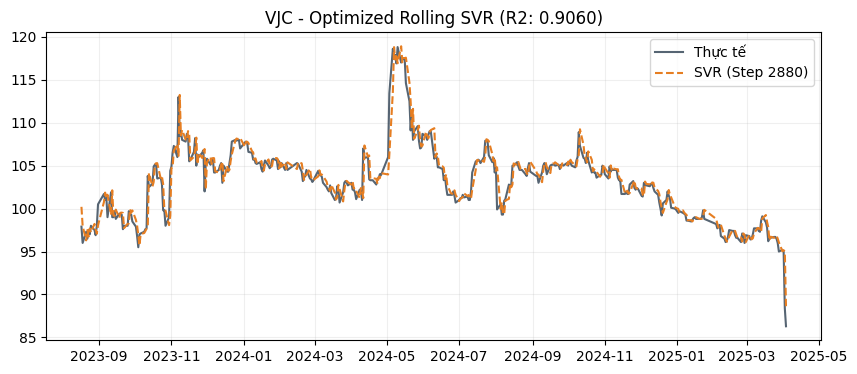

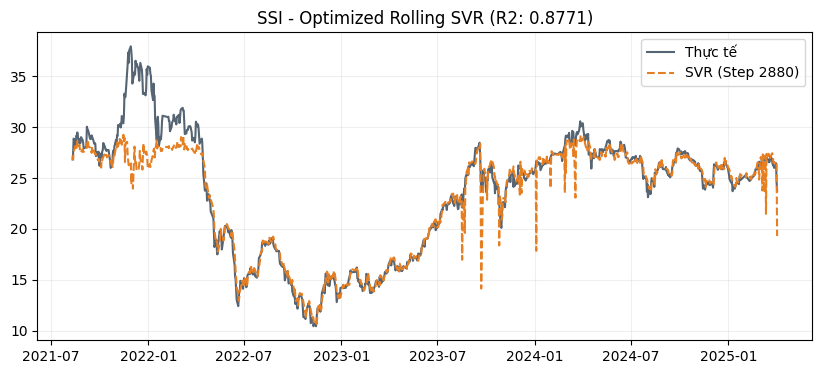

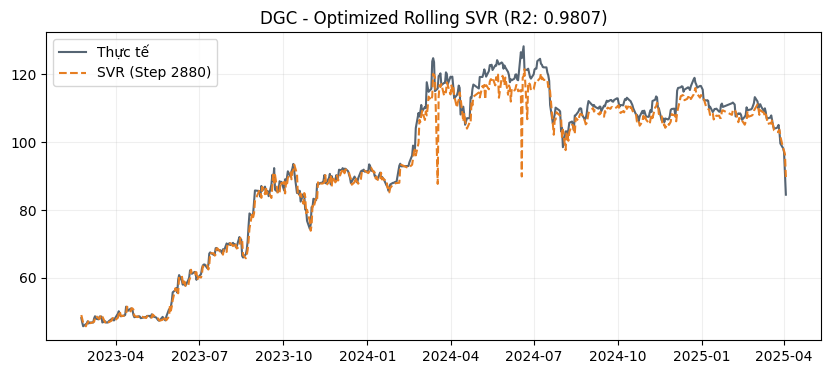

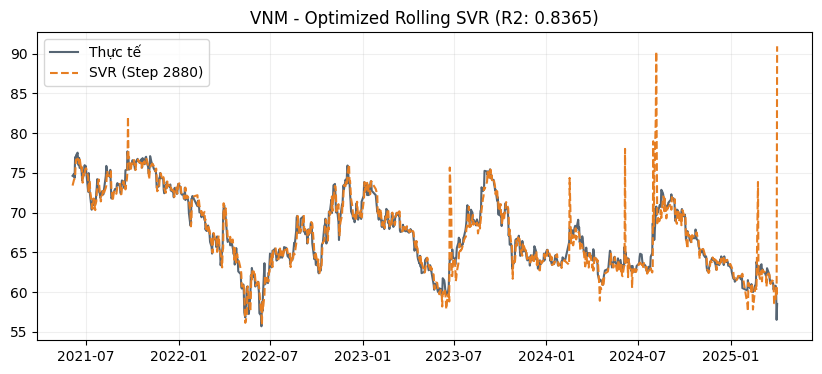

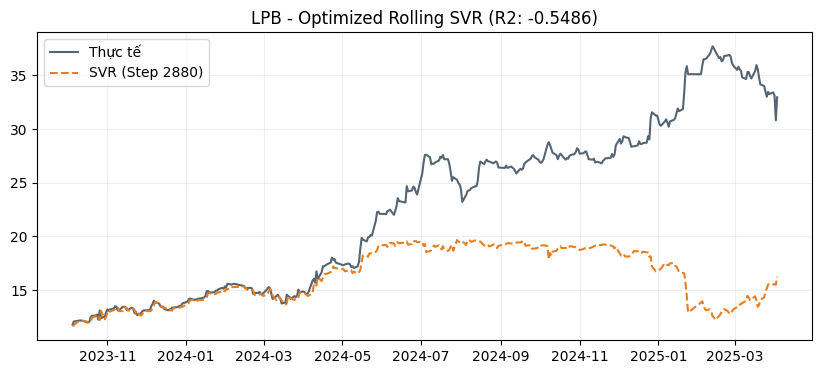

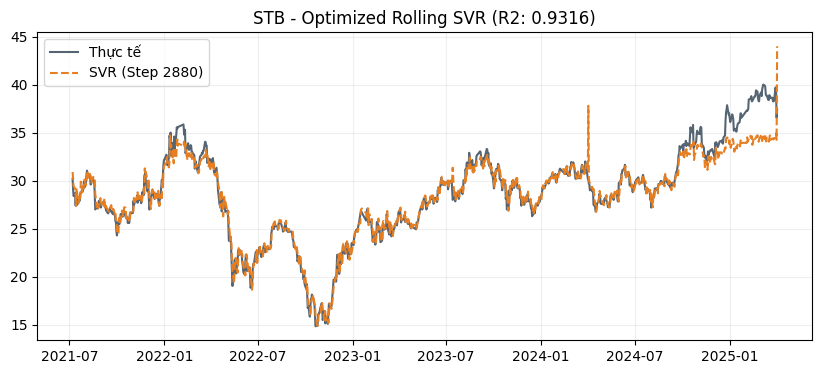


Mã CP    | MSE        | MAE      | R2      
MWG      | 12.70      | 2.40     | 0.8743  
HPG      | 0.30       | 0.39     | 0.9888  
SAB      | 165.71     | 6.63     | -3.8038 
BID      | 1.08       | 0.84     | 0.9288  
PLX      | 0.45       | 0.47     | 0.9803  
CTG      | 0.45       | 0.48     | 0.9849  
GVR      | 0.54       | 0.51     | 0.9797  
VHM      | 23.19      | 2.09     | 0.3797  
VCB      | 2.04       | 1.13     | 0.9642  
SSB      | 0.10       | 0.18     | 0.9361  
BCM      | 8.31       | 1.42     | 0.7597  
VIB      | 0.14       | 0.22     | 0.9495  
HDB      | 4.25       | 1.61     | 0.4938  
GAS      | 1.04       | 0.69     | 0.9480  
MSN      | 5.76       | 1.57     | 0.9791  
FPT      | 2336.38    | 26.64    | -1.2878 
ACB      | 1.50       | 0.78     | 0.8701  
TPB      | 0.31       | 0.24     | 0.7236  
VIC      | 6.32       | 1.08     | 0.9797  
SHB      | 0.09       | 0.16     | 0.9653  
VRE      | 3.93       | 1.27     | 0.5807  
MBB      | 0.17       | 0.29   

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import drive
from joblib import Parallel, delayed

# 1. Kết nối Drive
drive.mount('/content/drive', force_remount=True)

# 2. Cấu hình (Đường dẫn ITEC 2 từ ảnh của bạn)
folder_path = '/content/drive/MyDrive/ITEC 2/.vnstock'
vn30_2026 = [
    'MWG', 'HPG', 'SAB', 'BID', 'VPL', 'PLX', 'CTG', 'GVR', 'VHM', 'VCB',
    'SSB', 'BCM', 'VIB', 'HDB', 'GAS', 'MSN', 'FPT', 'ACB', 'TPB', 'VIC',
    'SHB', 'VRE', 'MBB', 'TCB', 'VPB', 'VJC', 'SSI', 'DGC', 'VNM', 'LPB', 'STB'
]
features = ['open', 'high', 'low', 'close', 'volume']
WINDOW_STEP = 2880  # Học lại sau mỗi 2880 phiên (năm)

def process_stock_rolling_step(symbol):
    file_path = os.path.join(folder_path, f"stock_data_{symbol}.csv")
    if not os.path.exists(file_path):
        return None

    try:
        df = pd.read_csv(file_path)
        df['time'] = pd.to_datetime(df['time'])
        df = df.sort_values('time').reset_index(drop=True)

        X_all = df[features].values
        y_all = df['close'].shift(-1).values
        X_all, y_all = X_all[:-1], y_all[:-1]

        split = int(len(X_all) * 0.8)
        train_X, train_y = list(X_all[:split]), list(y_all[:split])
        test_X, test_y = X_all[split:], y_all[split:]
        test_dates = df['time'].iloc[split:-1]

        predictions = []
        model = None
        scaler = None

        for i in range(len(test_X)):
            # TỐI ƯU: Chỉ huấn luyện lại khi đến bước nhảy (20 phiên) hoặc lần đầu tiên
            if i % WINDOW_STEP == 0 or model is None:
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(np.array(train_X))

                model = SVR(kernel='rbf', C=1000, gamma=0.01)
                model.fit(X_train_scaled, train_y)

            # Sử dụng model hiện tại để dự báo cho ngày hôm nay
            X_test_point = scaler.transform(test_X[i].reshape(1, -1))
            pred = model.predict(X_test_point)
            predictions.append(pred[0])

            # Cập nhật dữ liệu thực tế vào tập train để dùng cho các lần huấn luyện sau
            train_X.append(test_X[i])
            train_y.append(test_y[i])

        return {
            'symbol': symbol,
            'mse': mean_squared_error(test_y, predictions),
            'mae': mean_absolute_error(test_y, predictions),
            'r2': r2_score(test_y, predictions),
            'actual': test_y,
            'pred': predictions,
            'dates': test_dates
        }
    except Exception as e:
        return None

# --- CHẠY SONG SONG ---
print(f"Đang xử lý 31 mã với Window Step = {WINDOW_STEP}...")
results = Parallel(n_jobs=-1)(delayed(process_stock_rolling_step)(s) for s in vn30_2026)
results = [r for r in results if r is not None]


# --- XUẤT KẾT QUẢ ---
pdf_filename = 'Bao_Cao_SVR_Parallel_Step20.pdf'
summary_data = []

with PdfPages(pdf_filename) as pdf:
    for res in results:
        symbol = res['symbol']
        summary_data.append([symbol, f"{res['mse']:.2f}", f"{res['mae']:.2f}", f"{res['r2']:.4f}"])

        # Biểu đồ in trực tiếp
        plt.figure(figsize=(10, 4))
        plt.plot(res['dates'], res['actual'], label='Thực tế', color='#2c3e50', alpha=0.8)
        plt.plot(res['dates'], res['pred'], label=f'SVR (Step {WINDOW_STEP})', color='#e67e22', linestyle='--')
        plt.title(f"{symbol} - Optimized Rolling SVR (R2: {res['r2']:.4f})")
        plt.legend()
        plt.grid(True, alpha=0.2)
        pdf.savefig()
        plt.show()
        plt.close()

    # Bảng tổng hợp
    print("\n" + "="*50)
    print(f"{'Mã CP':<8} | {'MSE':<10} | {'MAE':<8} | {'R2':<8}")
    for row in summary_data:
        print(f"{row[0]:<8} | {row[1]:<10} | {row[2]:<8} | {row[3]:<8}")

print(f"\nĐã hoàn thành! File PDF: {pdf_filename}")